In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler


from src.auxiliares import dataframe_coeficientes
from src.config import DADOS_LIMPOS
from src.graficos import plot_coeficientes, plot_comparar_metricas_modelos
from src.models import RANDOM_STATE
from src.models import (
    grid_search_cv_classificador,
    treinar_e_validar_modelo_classificacao,
    organiza_resultados,
)

sns.set_theme(palette="bright")

In [3]:
df = pd.read_parquet(DADOS_LIMPOS)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.9 KB


In [3]:
X = df.drop(columns=["Species"])
y = df["Species"]

le = LabelEncoder()

y = le.fit_transform(y)

In [4]:
y[:5]

array([0, 0, 0, 0, 0])

In [5]:
le.classes_

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [6]:
le.inverse_transform([0, 1, 2])

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [7]:
kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

In [8]:
preprocessamento = Pipeline(
    steps=[
        ("scaler", StandardScaler())]
)

In [9]:
classificadores = {
    "DummyClassifier": {
        "preprocessor": None,
        "classificador": DummyClassifier(strategy="stratified")
    },
    "LogisticRegression": {
        "preprocessor": preprocessamento,
        "classificador": LogisticRegression()
    },
}

In [10]:
resultados = {
    nome_modelo: treinar_e_validar_modelo_classificacao(X, y, kf, **classificador, multi_class=True)
    for nome_modelo, classificador in classificadores.items()
}


df_resultados = organiza_resultados(resultados)


df_resultados

,model,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1_weighted,test_precision_weighted,test_recall_weighted,test_roc_auc_ovr,test_average_precision,time_seconds
0,DummyClassifier,0.003997,0.035182,0.36,0.357843,0.357438,0.355333,0.36,0.520462,0.343937,0.039179
1,DummyClassifier,0.001999,0.020986,0.3,0.302696,0.28708,0.286709,0.3,0.475583,0.325917,0.022985
2,DummyClassifier,0.002002,0.025137,0.36,0.359069,0.36,0.36,0.36,0.402815,0.308321,0.027138
3,LogisticRegression,0.034977,0.035996,1.0,1.0,1.0,1.0,1.0,1.0,0.7713,0.070973
4,LogisticRegression,0.01098,0.028983,0.92,0.919118,0.92,0.92,0.92,0.995172,0.762167,0.039963
5,LogisticRegression,0.01101,0.03397,0.94,0.941176,0.939948,0.940972,0.94,0.997623,0.842977,0.04498


In [11]:
df_resultados.groupby("model").mean().sort_values("test_accuracy", ascending=False)

,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1_weighted,test_precision_weighted,test_recall_weighted,test_roc_auc_ovr,test_average_precision,time_seconds
model,,,,,,,,,,
LogisticRegression,0.018989,0.032983,0.953333,0.953431,0.953316,0.953657,0.953333,0.997599,0.792148,0.051972
DummyClassifier,0.002666,0.027102,0.34,0.339869,0.334839,0.334014,0.34,0.466287,0.326058,0.029768


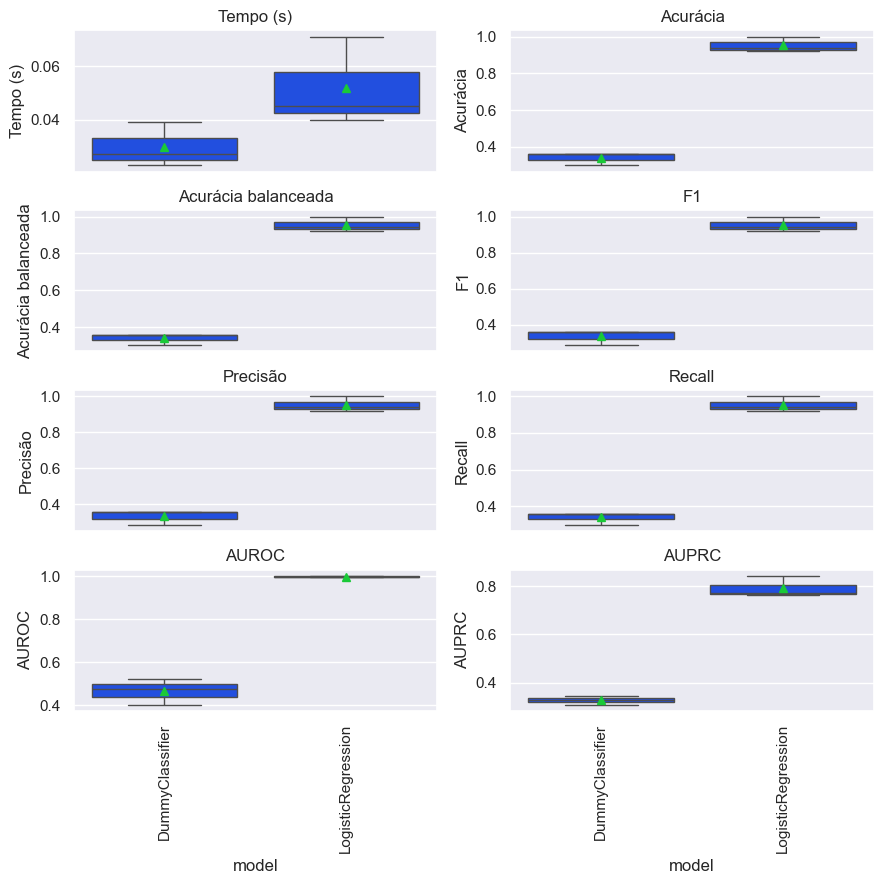

In [12]:
plot_comparar_metricas_modelos(df_resultados, multi_class=True)

In [13]:
param_grid = {
    "clf__C": [0.01, 0.1, 1, 10, 100],
    "clf__l1_ratio": [0.0, 0.1, 0.5, 1.0],
    "clf__class_weight": [None, "balanced"],
}

In [14]:
clf = LogisticRegression(solver="saga", random_state=RANDOM_STATE)

grid_search = grid_search_cv_classificador(
    clf, param_grid, kf, preprocessamento, refit_metric="accuracy", multi_class=True
)

grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.01, 0.1, ...], 'clf__class_weight': [None, 'balanced'], 'clf__l1_ratio': [0.0, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'balanced_accuracy', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1

In [15]:
grid_search.fit(X, y)

Fitting 3 folds for each of 40 candidates, totalling 120 fits


c:\Users\gabri\anaconda3\envs\IrisSpecies\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.01, 0.1, ...], 'clf__class_weight': [None, 'balanced'], 'clf__l1_ratio': [0.0, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'balanced_accuracy', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1

In [16]:
grid_search.best_params_

{'clf__C': 10, 'clf__class_weight': None, 'clf__l1_ratio': 0.0}

In [17]:
grid_search.best_score_

np.float64(0.9666666666666667)

In [18]:
grid_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exceptio

In [19]:
grid_search.best_estimator_["preprocessor"].get_feature_names_out()

array(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'],
      dtype=object)

In [20]:
grid_search.best_estimator_["clf"].coef_

array([[-1.78846012,  1.8734438 , -3.54217753, -3.36061601],
       [ 1.32204016, -0.35798158, -1.45975813, -1.42484871],
       [ 0.46641996, -1.51546223,  5.00193566,  4.78546472]])

In [21]:
grid_search.best_estimator_["clf"].classes_

array([0, 1, 2])

Em uma **classificação multiclasse** utilizando regressão logística na abordagem **multinomial**, um único modelo é ajustado para prever todas as classes simultaneamente. Nesse modelo multinomial, são gerados múltiplos conjuntos de coeficientes, um para cada classe, que são usados para calcular as probabilidades relativas entre todas as classes.

1. **Vários arrays para várias classes**: Em problemas de classificação multiclasse, como há mais de duas classes, a regressão logística multinomial retorna um conjunto de coeficientes para cada classe. Cada array em `coef_` corresponde à relação entre as features e a probabilidade de uma classe específica ser a previsão correta, levando em consideração as outras classes simultaneamente.

2. **Forma de `coef_`**:
   - Se houver `n_features` features e `n_classes` classes, `coef_` terá a forma `(n_classes, n_features)`. Cada linha da matriz `coef_` representa um conjunto de coeficientes para uma classe específica, enquanto cada coluna se refere ao peso de uma feature para essa classe.

3. **Exemplo de interpretação**: Se `coef_` retorna uma matriz de coeficientes, cada linha dessa matriz corresponde à influência das features para uma classe específica. Os coeficientes positivos indicam que o aumento no valor de uma feature aumenta a probabilidade de previsão da classe correspondente. Coeficientes negativos indicam que o aumento no valor da feature diminui essa probabilidade. A magnitude do coeficiente reflete a força da influência de uma feature sobre a classe alvo.

4. **Importância dos coeficientes**:
   - **Coeficiente positivo**: Um coeficiente positivo significa que, à medida que o valor da feature aumenta, a probabilidade da classe associada a esse conjunto de coeficientes ser prevista também aumenta.
   - **Coeficiente negativo**: Um coeficiente negativo indica que o aumento no valor da feature reduz a probabilidade de a classe associada ser prevista.
   - **Magnitude**: A magnitude dos coeficientes reflete a força da relação entre a feature e a classe correspondente.


In [23]:
grid_search.best_estimator_["clf"].coef_[0]

array([-1.78846012,  1.8734438 , -3.54217753, -3.36061601])

In [28]:
df_coefs0 = dataframe_coeficientes(
    grid_search.best_estimator_["clf"].coef_[0], 
    grid_search.best_estimator_["preprocessor"].get_feature_names_out()
    )

df_coefs1 = dataframe_coeficientes(
    grid_search.best_estimator_["clf"].coef_[1], 
    grid_search.best_estimator_["preprocessor"].get_feature_names_out()
    )

df_coefs2 = dataframe_coeficientes(
    grid_search.best_estimator_["clf"].coef_[2], 
    grid_search.best_estimator_["preprocessor"].get_feature_names_out()
    )

In [25]:
le.inverse_transform([0, 1, 2])

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

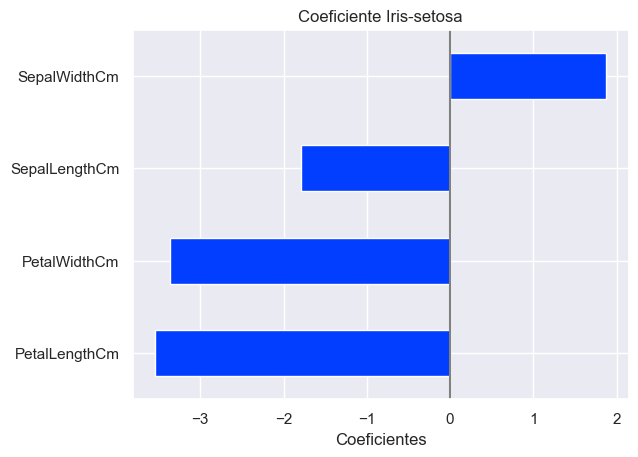

In [33]:
plot_coeficientes(df_coefs0, tituto="Coeficiente Iris-setosa")

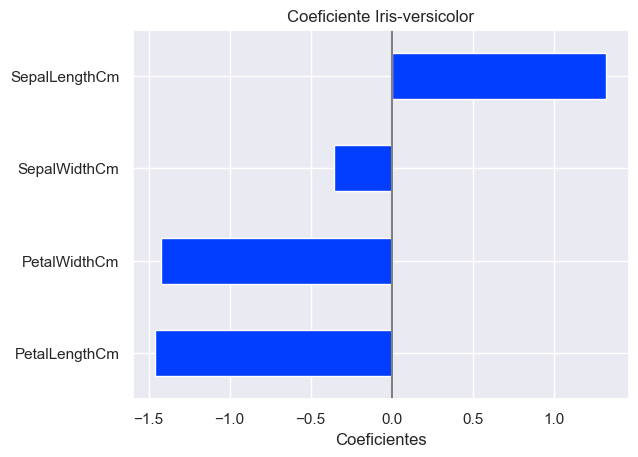

In [34]:
plot_coeficientes(df_coefs1, tituto="Coeficiente Iris-versicolor")

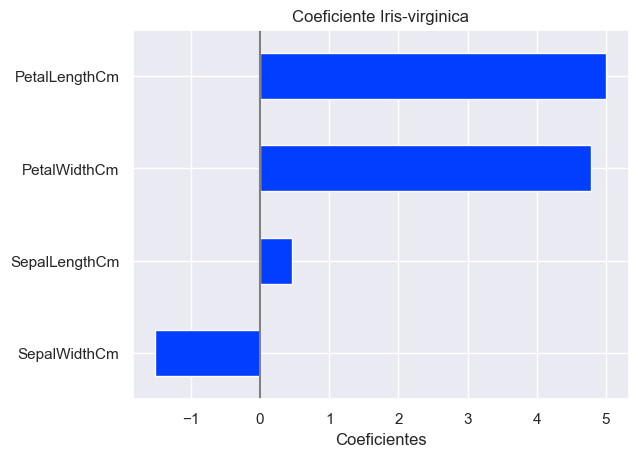

In [35]:
plot_coeficientes(df_coefs2, tituto="Coeficiente Iris-virginica")

#### Características que aumentam a probabilidade de ser da espécie da Planata.
- Iris-setosa: Sépalas mais largas e Pétalas menores.
- Iris-versicolor: tamanho intermediário.
- Iris-virginica: Pétalas maiores.

In [37]:
X_scaled = grid_search.best_estimator_["preprocessor"].transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=grid_search.best_estimator_["preprocessor"].get_feature_names_out())

df_scaled = pd.concat([X_scaled, pd.Series(le.inverse_transform(y), name="Species")], axis=1)

df_scaled.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,-0.900681,1.032057,-1.341272,-1.312977,Iris-setosa
1,-1.143017,-0.124958,-1.341272,-1.312977,Iris-setosa
2,-1.385353,0.337848,-1.398138,-1.312977,Iris-setosa
3,-1.506521,0.106445,-1.284407,-1.312977,Iris-setosa
4,-1.021849,1.263460,-1.341272,-1.312977,Iris-setosa


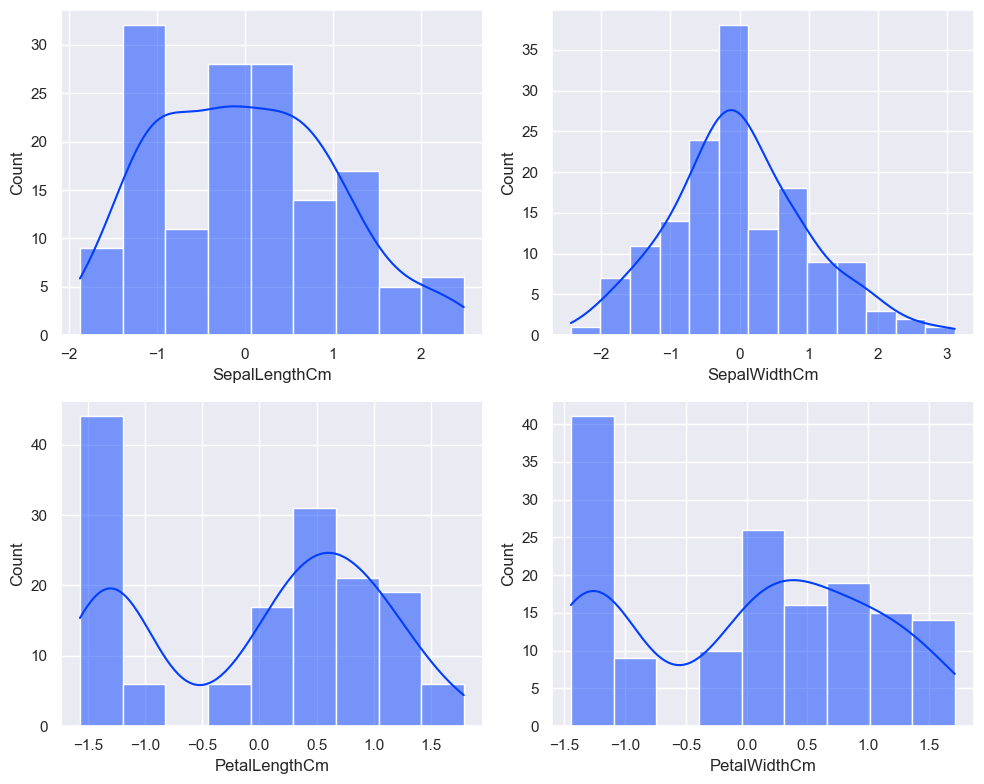

In [43]:
fig,axs = plt.subplots(2, 2, figsize=(10, 8))

for ax,coluna in zip(axs.flatten(), X_scaled.columns):
    sns.histplot(x=coluna, data=df_scaled, ax=ax, kde=True)

plt.tight_layout()
plt.show()

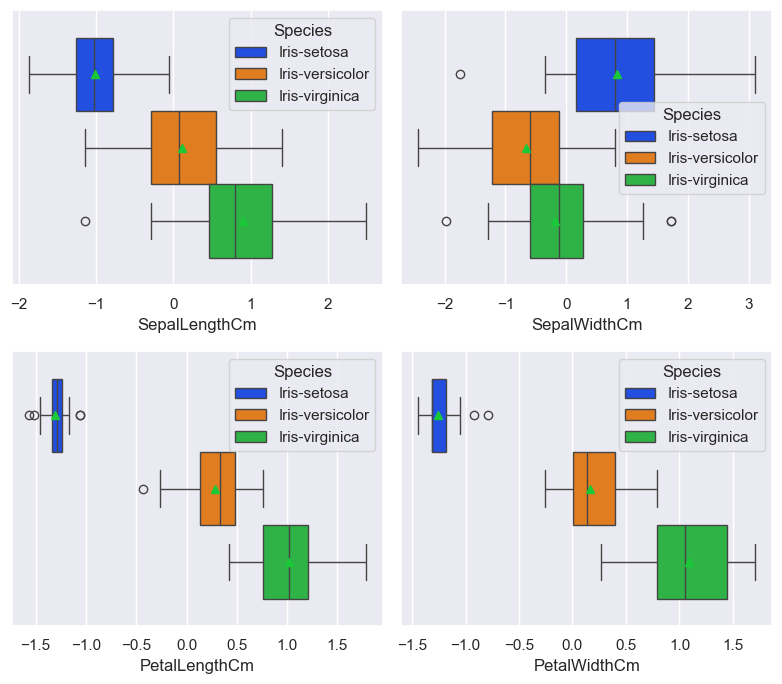

In [48]:
fig,axs = plt.subplots(2, 2, figsize=(8, 7))


for ax,coluna in zip(axs.flatten(), X_scaled.columns):
    sns.boxplot( x=coluna, data=df_scaled, ax=ax, hue='Species', showmeans=True)


plt.tight_layout()
plt.show()